# 01 — Initial exploration

**Mock data only.** This notebook is for building/testing the pipeline
(DB → pandas → plots), not for drawing conclusions about vehicle
behavior — any correlations here are artifacts of the mock generator,
not real signal. Swapping in real data later should require no changes
below, just new rows underneath.

In [1]:
import sys, os

# diagnostic — confirm kernel/env are what we expect before doing anything else
print("Python executable:", sys.executable)
print("PYTHONPATH env var:", repr(os.environ.get("PYTHONPATH")))
print("ROS-looking paths in sys.path:", [p for p in sys.path if "ros" in p.lower()] or "none")

Python executable: /home/buvindu-suraweera/vehicle-telemetry-platform/analytics/.venv/bin/python
PYTHONPATH env var: None
ROS-looking paths in sys.path: none


In [2]:
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.session_summary import load_session_telemetry, list_sessions

sns.set_theme(style="darkgrid")

## Connection check

In [3]:
sessions = list_sessions()
sessions

,session_id,driver_id,started_at,ended_at,notes,row_count
0,live_001,driver_a,2026-07-16 16:18:08.923735+05:30,2026-07-16 18:06:05.448023+05:30,Live OBD session,64619
1,mock_001,driver_a,2026-07-16 16:18:08.923735+05:30,2026-07-16 18:06:05.448023+05:30,Mock data session,64619
2,580b6bf4d35a496ba3d0492feae04a60,driver_a,2026-07-23 18:47:05.252985+05:30,2026-07-23 18:49:35.700267+05:30,NaN,0
3,f54d93764251441ab94d3fd89a96e910,NaN,2026-07-26 11:56:52.935421+05:30,2026-07-26 11:57:23.600341+05:30,UI session creation test 1,0
4,68547f507679411a99ab91fe356ded46,driver_a,2026-07-26 11:59:00.670896+05:30,2026-07-26 11:59:18.080642+05:30,NaN,0
5,real_obd_001,driver_a,2026-07-26 15:17:21.037000+05:30,2026-07-26 15:49:11.384000+05:30,"Real vehicle OBD, mock IMU — first hardware ca...",2410
6,0eec1e0cecec47c4acd40b71978c2359,NaN,2026-09-22 18:27:02.714822+05:30,2026-09-22 21:00:57.935955+05:30,NaN,17508
7,82a0afa3f743440a8d32bc5cde1dc1a6,NaN,2026-09-23 17:55:52.385720+05:30,2026-09-23 18:32:01.189343+05:30,Second test; taking place on 23 Sep 2026,21542


## Pull raw telemetry

Adjust `session_id` below to whichever session the migrated mock data
actually landed under.

In [6]:
SESSION_ID = "82a0afa3f743440a8d32bc5cde1dc1a6"

df = load_session_telemetry(SESSION_ID)
print(df.shape)
df.head()

(21542, 12)


,time,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z,latitude,longitude,node_id
0,2026-09-23 17:56:07.046000+05:30,0.0,842.8,18.4,56.0,50.2,-0.089,9.405,3.518,None,None,None
1,2026-09-23 17:56:07.147000+05:30,0.0,842.8,18.4,56.0,50.2,-0.055,9.460,2.975,None,None,None
2,2026-09-23 17:56:07.246000+05:30,0.0,842.8,18.4,56.0,50.2,-0.153,9.206,3.710,None,None,None
3,2026-09-23 17:56:07.346000+05:30,0.0,842.8,18.4,56.0,50.2,-0.331,9.274,3.719,None,None,None
4,2026-09-23 17:56:07.447000+05:30,0.0,NaN,18.4,56.0,50.2,0.196,9.647,3.042,None,None,None


In [7]:
df.describe()

,speed_kmh,rpm,throttle_pct,coolant_temp_c,engine_load_pct,accel_x,accel_y,accel_z
count,21191.000000,21206.000000,21206.000000,21194.000000,21136.000000,21530.000000,21530.000000,21530.000000
mean,12.437780,1138.964024,19.262195,85.496697,53.188796,-0.097539,9.191512,4.038354
std,11.815575,323.520565,2.592359,7.531097,15.834022,0.579667,0.482992,0.636685
min,0.000000,689.000000,16.100000,56.000000,28.200000,-3.226000,4.352000,0.623000
25%,0.000000,810.800000,17.600000,86.000000,40.800000,-0.448000,8.905000,3.633000
50%,9.000000,1170.200000,18.400000,88.000000,49.000000,-0.101000,9.204000,4.052000
75%,22.000000,1339.000000,20.000000,89.000000,61.600000,0.263000,9.477000,4.457000
max,47.000000,2605.200000,35.300000,95.000000,96.500000,4.850000,12.162000,7.142000


## First-look plots

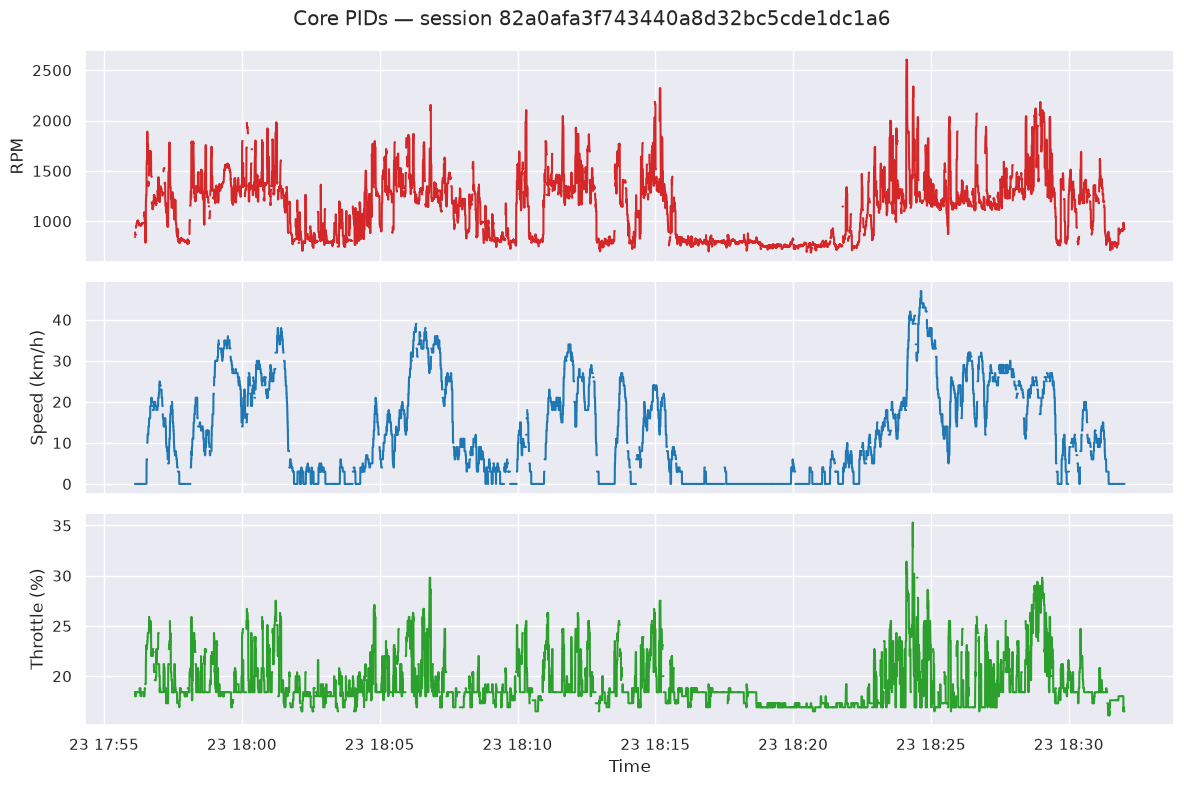

In [8]:
# Core PIDs over time — sanity check that the shapes look sane, not an
# analysis conclusion
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["time"], df["rpm"], color="tab:red")
axes[0].set_ylabel("RPM")

axes[1].plot(df["time"], df["speed_kmh"], color="tab:blue")
axes[1].set_ylabel("Speed (km/h)")

axes[2].plot(df["time"], df["throttle_pct"], color="tab:green")
axes[2].set_ylabel("Throttle (%)")
axes[2].set_xlabel("Time")

fig.suptitle(f"Core PIDs — session {SESSION_ID}")
fig.tight_layout()

<Axes: xlabel='time'>

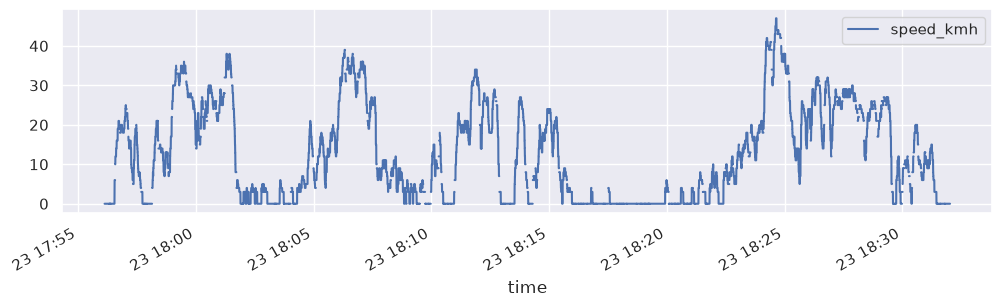

In [9]:
df["speed_kmh"].describe()
df.plot(x="time", y="speed_kmh", figsize=(12, 3))

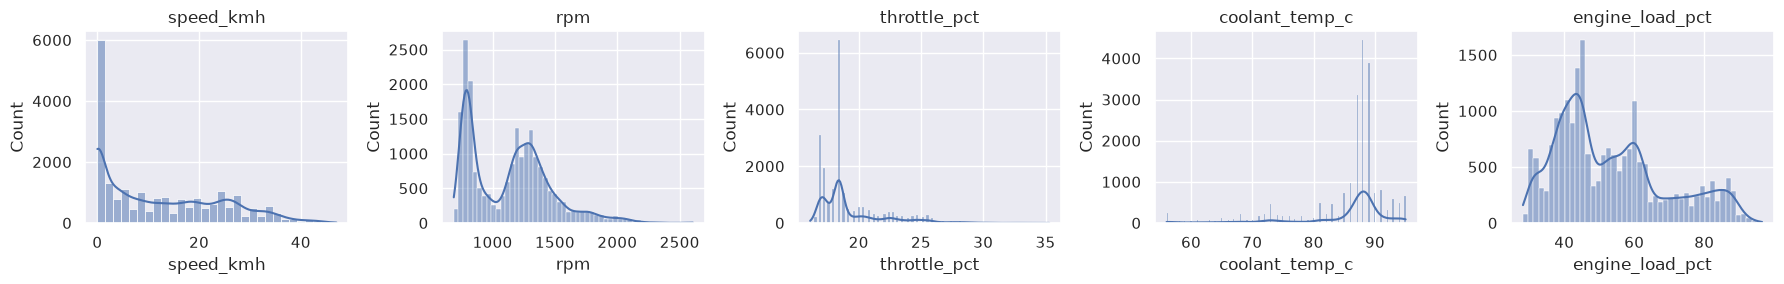

In [10]:
# Distributions — quick shape check across all core PIDs
core_pids = ["speed_kmh", "rpm", "throttle_pct", "coolant_temp_c", "engine_load_pct"]

fig, axes = plt.subplots(1, len(core_pids), figsize=(18, 3))
for ax, col in zip(axes, core_pids):
    sns.histplot(df[col].dropna(), ax=ax, kde=True)
    ax.set_title(col)
fig.tight_layout()

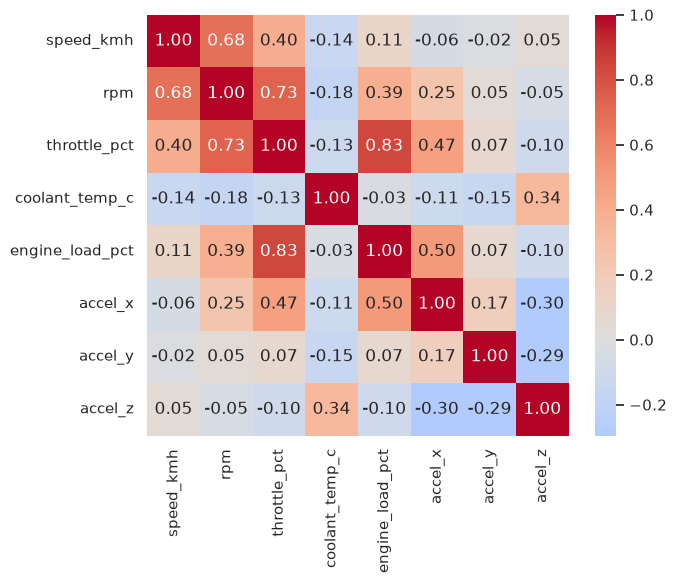

In [11]:
# Correlation matrix — pipeline check only. Do NOT read anything into
# these values while the data is synthetic — correlations here reflect
# the mock generator's own logic, not vehicle behavior.
corr = df[core_pids + ["accel_x", "accel_y", "accel_z"]].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()

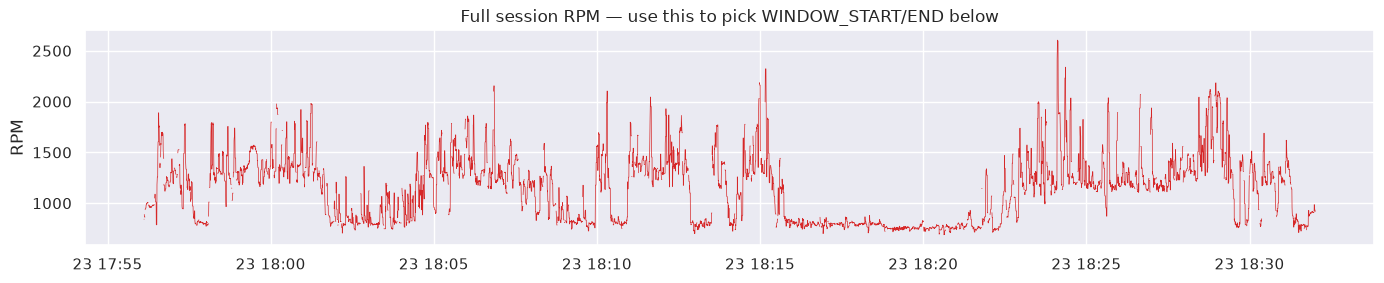

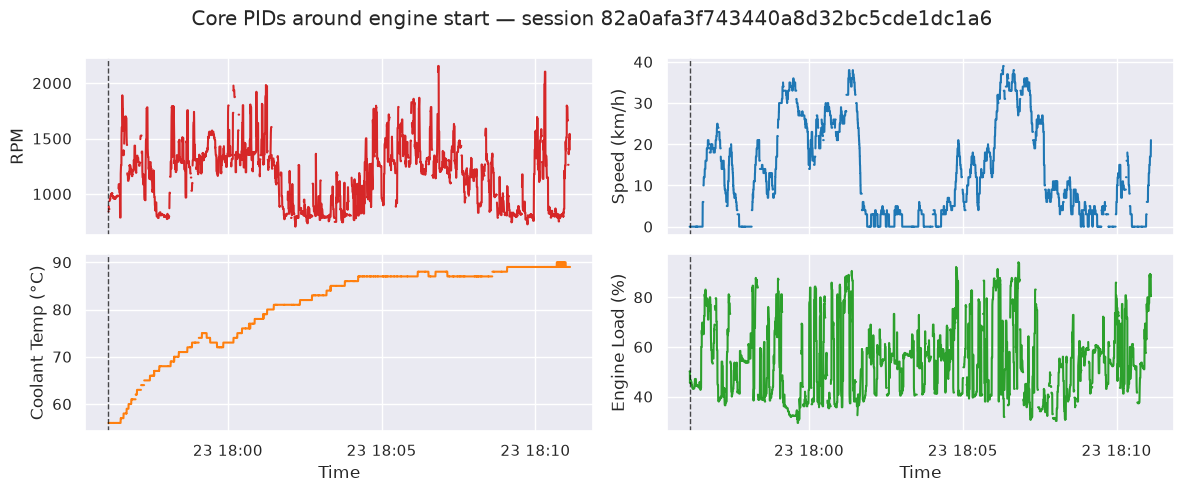

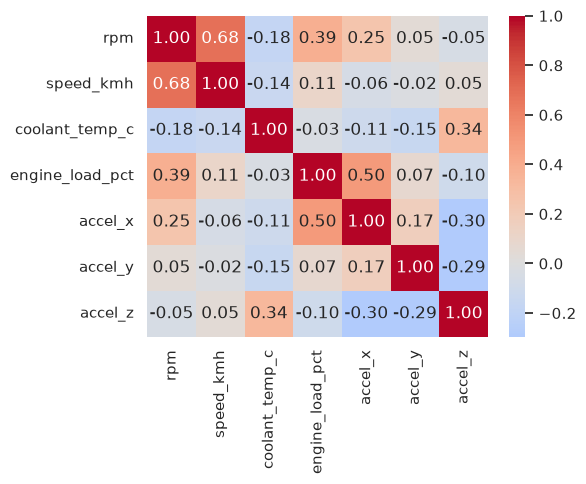

In [ ]:
# --- Eyeball pass: full session, single unscaled plot, just to find the window ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df["time"], df["rpm"], color="tab:red", linewidth=0.5)
ax.set_ylabel("RPM")
ax.set_title("Full session RPM — use this to pick WINDOW_START/END below")
fig.tight_layout()


# --- one flag + one window control every placeholder-data figure ---
IS_PLACEHOLDER = False  # flip to False once real wired data is loaded
engine_start_time = pd.Timestamp("2026-09-23 17:56:07.046000+05:30")  # set to the real timestamp once available or leave as None

# Set these by eyeballing the cell above (or automatically once
# engine_start_time is known for the real session)
WINDOW_SECONDS_BEFORE = 10
WINDOW_SECONDS_AFTER = 900

if engine_start_time is not None:
    window_start = engine_start_time - pd.Timedelta(seconds=WINDOW_SECONDS_BEFORE)
    window_end = engine_start_time + pd.Timedelta(seconds=WINDOW_SECONDS_AFTER)
else:
    # manual fallback for now — set these directly after eyeballing above
    window_start = df["time"].iloc[0]
    window_end = df["time"].iloc[0] + pd.Timedelta(seconds=WINDOW_SECONDS_BEFORE + WINDOW_SECONDS_AFTER)

df_window = df[(df["time"] >= window_start) & (df["time"] <= window_end)]

def watermark_if_placeholder(fig):
    if IS_PLACEHOLDER:
        fig.text(0.5, 0.5, "PLACEHOLDER — feasibility BT data, not final",
                  fontsize=24, color="red", alpha=0.35,
                  ha="center", va="center", rotation=30)

# --- Core PIDs, 2x2 grid — WINDOWED for legibility ---
core_pids_for_paper = ["rpm", "speed_kmh", "coolant_temp_c", "engine_load_pct"]
labels = {"rpm": "RPM", "speed_kmh": "Speed (km/h)",
          "coolant_temp_c": "Coolant Temp (°C)", "engine_load_pct": "Engine Load (%)"}
colors = {"rpm": "tab:red", "speed_kmh": "tab:blue",
          "coolant_temp_c": "tab:orange", "engine_load_pct": "tab:green"}

fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex=True)
for ax, col in zip(axes.flatten(), core_pids_for_paper):
    ax.plot(df_window["time"], df_window[col], color=colors[col])
    ax.set_ylabel(labels[col])
    if engine_start_time is not None:
        ax.axvline(engine_start_time, color="black", linestyle="--", linewidth=1, alpha=0.7)

axes[1, 0].set_xlabel("Time")
axes[1, 1].set_xlabel("Time")
fig.suptitle(f"Core PIDs around engine start — session {SESSION_ID}")
fig.tight_layout()
watermark_if_placeholder(fig)

# --- Correlation matrix — FULL session, not windowed ---
corr_cols = core_pids_for_paper + ["accel_x", "accel_y", "accel_z"]
corr = df[corr_cols].corr()   # note: df, not df_window
fig2, ax2 = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax2)
fig2.tight_layout()
watermark_if_placeholder(fig2)

In [13]:
df["time"].head()

0   2026-09-23 17:56:07.046000+05:30
1   2026-09-23 17:56:07.147000+05:30
2   2026-09-23 17:56:07.246000+05:30
3   2026-09-23 17:56:07.346000+05:30
4   2026-09-23 17:56:07.447000+05:30
Name: time, dtype: datetime64[us, Asia/Colombo]

In [14]:
print(df["time"].head(10))
print(df["time"].diff().dt.total_seconds().value_counts().sort_index().head(10))

0   2026-09-23 17:56:07.046000+05:30
1   2026-09-23 17:56:07.147000+05:30
2   2026-09-23 17:56:07.246000+05:30
3   2026-09-23 17:56:07.346000+05:30
4   2026-09-23 17:56:07.447000+05:30
5   2026-09-23 17:56:07.546000+05:30
6   2026-09-23 17:56:07.646000+05:30
7   2026-09-23 17:56:07.746000+05:30
8   2026-09-23 17:56:07.846000+05:30
9   2026-09-23 17:56:07.947000+05:30
Name: time, dtype: datetime64[us, Asia/Colombo]
time
0.002        8
0.003        7
0.008        1
0.059        1
0.097        3
0.098      163
0.099     3328
0.100    14480
0.101     3459
0.102       87
Name: count, dtype: int64


Empirical expected interval: 0.100s (10.00 Hz)
Session duration: 2154.1s
Expected reads per PID: 21541
rpm                98.4
speed_kmh          98.4
coolant_temp_c     98.4
engine_load_pct    98.1
Name: completeness_pct, dtype: float64

Overall (mean across core PIDs): 98.3%

Connection-loss events (gap > 0.30s): 1
Total lost time: 1.3s (0.06% of session)
0.50    0.100
0.75    0.100
0.90    0.101
0.95    0.101
0.99    0.101
Name: time, dtype: float64
[1.44]


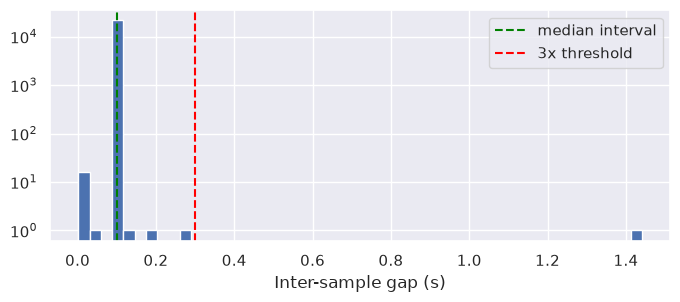

In [16]:
# --- Acquisition Performance: read completeness & connection-loss events ---

core_pids = ["rpm", "speed_kmh", "coolant_temp_c", "engine_load_pct"]

# 1. Empirically-derived expected interval
deltas = df["time"].diff().dt.total_seconds().dropna()
expected_interval_s = deltas.median()

session_duration_s = (df["time"].iloc[-1] - df["time"].iloc[0]).total_seconds()
expected_count = session_duration_s / expected_interval_s

print(f"Empirical expected interval: {expected_interval_s:.3f}s ({1/expected_interval_s:.2f} Hz)")
print(f"Session duration: {session_duration_s:.1f}s")
print(f"Expected reads per PID: {expected_count:.0f}")

# 2. Per-PID completeness. A "loss" is either a fully missing row (gap)
# or a row present with that PID left null (the ingestor's partial-row
# fallback per mqtt-topics.md) -- both collapse into one category here,
# per the decision not to distinguish failure layers for this paper.
completeness = {pid: 100 * df[pid].notna().sum() / expected_count for pid in core_pids}
completeness_df = pd.Series(completeness, name="completeness_pct").round(1)
print(completeness_df)
print(f"\nOverall (mean across core PIDs): {completeness_df.mean():.1f}%")

# 3. Connection-loss events: gaps well above the normal cadence.
GAP_THRESHOLD_MULTIPLIER = 3  # see note below before trusting this
gap_threshold_s = expected_interval_s * GAP_THRESHOLD_MULTIPLIER

loss_events = deltas[deltas > gap_threshold_s]
total_lost_time_s = (loss_events - expected_interval_s).sum()

print(f"\nConnection-loss events (gap > {gap_threshold_s:.2f}s): {len(loss_events)}")
print(f"Total lost time: {total_lost_time_s:.1f}s "
      f"({100*total_lost_time_s/session_duration_s:.2f}% of session)")


fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(deltas, bins=50)
ax.set_yscale("log")
ax.axvline(expected_interval_s, color="green", linestyle="--", label="median interval")
ax.axvline(gap_threshold_s, color="red", linestyle="--", label=f"{GAP_THRESHOLD_MULTIPLIER}x threshold")
ax.set_xlabel("Inter-sample gap (s)")
ax.legend()

print(deltas.quantile([0.5, 0.75, 0.9, 0.95, 0.99]))
print(sorted(loss_events.round(2).tolist()))


In [17]:
# Second version of the analysis check for when sub-second precision is not available

core_pids = ["rpm", "speed_kmh", "coolant_temp_c", "engine_load_pct"]

session_start, session_end = df["time"].iloc[0], df["time"].iloc[-1]
expected_seconds = int((session_end - session_start).total_seconds()) + 1
df["second"] = df["time"].dt.floor("s")

# Per-PID completeness: fraction of whole seconds with >=1 non-null reading
completeness = {pid: 100 * df.loc[df[pid].notna(), "second"].nunique() / expected_seconds
                for pid in core_pids}
print(pd.Series(completeness, name="completeness_pct").round(1))
print(f"\nOverall (mean across core PIDs): {pd.Series(completeness, name="completeness_pct").round(1).mean()}%")

# Connection-loss events: runs of consecutive missing whole-seconds
all_seconds = pd.date_range(session_start.floor("s"), session_end.floor("s"), freq="1s")
missing = sorted(set(all_seconds) - set(df["second"]))

events, run = [], None
for s in missing:
    if run and (s - run[-1]).total_seconds() == 1:
        run.append(s)
    else:
        if run: events.append(run)
        run = [s]
if run: events.append(run)

MIN_LOSS_SECONDS = 2  # a single missing second alone isn't flagged
loss_events = [e for e in events if len(e) >= MIN_LOSS_SECONDS]
total_lost_s = sum(len(e) for e in loss_events)

print(f"Connection-loss events (>= {MIN_LOSS_SECONDS}s): {len(loss_events)}")
print(f"Total lost time: {total_lost_s}s ({100*total_lost_s/expected_seconds:.2f}% of session)")

rpm                 99.9
speed_kmh          100.0
coolant_temp_c     100.0
engine_load_pct     99.8
Name: completeness_pct, dtype: float64

Overall (mean across core PIDs): 99.925%
Connection-loss events (>= 2s): 0
Total lost time: 0s (0.00% of session)


In [18]:
missing_singles = sorted(set(pd.date_range(session_start.floor("s"), session_end.floor("s"), freq="1s")) - set(df["second"]))
print(missing_singles)

[]


In [19]:
print(df[core_pids].isna().sum())

rpm                336
speed_kmh          351
coolant_temp_c     348
engine_load_pct    406
dtype: int64
